# Notebook 07 — Validación box-prompt vs point-prompt en SAM3 (Paso 4.0)

## Idea

Antes de invertir las ~60h de las Etapas 1+2 descriptas en `plan/detection-segmentation-guide.md`
(detector YOLO + segmentador SAM3), este notebook corre el **Paso 4.0** de esa guía: una
validación barata (sin entrenar nada) de si SAM3 puede aislar una sola traza diagonal cuando se
le da como prompt una **bounding box** que también roza/superpone a una traza vecina, comparado
contra darle como prompt un **punto único** sobre esa misma traza.

Los prompts **no se dibujan a mano** en un editor de imágenes — se calculan programáticamente a
partir del ground truth exacto de `synthkymo` (`positions.csv`), eligiendo deliberadamente un
caso denso/con cruce (la traza cuya caja más se superpone con otra) en vez de un caso fácil.

## Qué se compara

|        | Baseline A                                                    | Baseline B                                |
| ------ | ------------------------------------------------------------- | ----------------------------------------- |
| Prompt | bounding box ajustada a la traza elegida                      | punto único (centroide de esa misma caja) |
| Modelo | `Sam3TrackerModel` / `Sam3TrackerProcessor` (`facebook/sam3`) | mismo modelo, mismo checkpoint            |

**Por qué `Sam3TrackerModel` y no `Sam3Model`** (el que usa `03_roi_sintetico_sam3.ipynb`):
`Sam3Processor.__call__` sólo acepta `input_boxes` y `text` — no soporta prompts de punto en
absoluto (verificado directamente contra la librería instalada, no supuesto). `Sam3TrackerModel`/
`Sam3TrackerProcessor` es el componente tipo-SAM2 dentro de la misma familia SAM3 (el que usa
`Sam3VideoModel` internamente como `tracker_model`), y sí acepta `input_points`+`input_labels`
además de `input_boxes`, desde el mismo checkpoint ya cacheado (`facebook/sam3`). Usar la
**misma clase de modelo** para ambos baselines mantiene la comparación limpia: la única variable
que cambia es el tipo de prompt, no el modelo.

## Resultado esperado de este notebook

Un **registro**, no un veredicto final, de cómo se comporta cada prompt en un caso difícil — para
alimentar la tabla de comparación de la sección 6 de la guía. Un solo ejemplo no alcanza para
descartar un baseline entero; correr esta notebook con 2–3 seeds distintos antes de sacar
conclusiones (ver sección 7).


---

## 0. Setup


In [15]:
import sys
import itertools
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
import torch
from PIL import Image

sys.path.append(str(Path("..") / "src"))

if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")
print(f"Device: {device}")


def norm_uint8(arr):
    """Estira a [0,255] uint8 por percentiles (para visualizar/pasar a PIL, no para métricas)."""
    lo, hi = np.percentile(arr, 1), np.percentile(arr, 99.5)
    return np.clip(
        (arr.astype(np.float32) - lo) / max(hi - lo, 1e-6) * 255, 0, 255
    ).astype(np.uint8)


def _to_bf16(inputs):
    """Mismo helper que 03_roi_sintetico_sam3.ipynb: castea floats al dtype del modelo."""
    return {
        k: (v.to(dtype=torch.bfloat16) if v.is_floating_point() else v)
        for k, v in inputs.items()
    }

Device: mps


## 1. Generar un kymógrafo sintético denso (con cruces)

Mismo `CONFIG` "realista" que `03_roi_sintetico_sam3.ipynb` (mismos valores de `config.yaml`),
pero con `type_counts` de `anterograde`/`retrograde` subidos (2+0 → 3+3) para forzar cruces —
el Paso 4.0 de la guía pide explícitamente probar un caso denso, no el caso disperso por
defecto.


In [16]:
from synthkymo.pipeline import generate

SEED = 42  # cambiar y re-correr para juntar mas de un caso -- ver seccion 7
print(f"Seed: {SEED}")

CONFIG = {
    "general": {
        "duration_s": 30.0,
        "fps": 2.0,
        "pixel_scale_um": 0.07,
        "bit_depth": 8,
        "seed": SEED,
    },
    "particles": {
        "speed_um_s": {"min": -1.0, "max": 1.0},
        "segment_duration_s": {"min": 1.0, "max": 8.0},
        "pause_probability": 0.3,
        "appear_disappear": {"enabled": False, "prob": 0.3},
        "size_um": {"min": 0.1, "max": 0.25},
        "brightness": {"min": 0.13, "max": 0.5},
        "size_jitter": 0.0,
        "brightness_jitter": 0.0,
        "type_counts": {
            # subido vs. el escenario "realista" de NB03 (static=4, anterograde=2, resto 0)
            # para garantizar densidad/cruces -- ver Idea arriba.
            "static": 2,
            "anterograde": 3,
            "retrograde": 3,
            "pure_anterograde": 0,
            "pure_retrograde": 0,
            "bidirectional": 0,
        },
    },
    "preview": {
        "kymograph_height": 2.5,
        "position_time_height": 2.5,
        "label_size": 8,
    },
    "movie": {
        "width_px": 480,
        "height_px": 480,
        "path": {"n_control_points": 4},
        "tube": {"width_um": 0.5, "brightness": 0.2, "variation": 0.5},
        "noise": {
            "background": 0.05,
            "read_sigma": 0.02,
            "shot": {"strength": 0.0},
            "hot_pixels": {"density": 0.0, "dead_fraction": 0.3},
            "illumination": {"unevenness": 0.0},
            "photobleaching": {"end_fraction": 1.0},
        },
        "artifacts": {
            "static_particles": {
                "count": 5,
                "size_um": {"min": 0.2, "max": 0.6},
                "brightness": {"min": 0.3, "max": 0.8},
            },
            "tails": {
                "count": 3,
                "length_um": {"min": 1.0, "max": 3.0},
                "brightness": {"min": 0.2, "max": 0.5},
            },
            "smoke": {
                "count": 4,
                "size_um": {"min": 2.0, "max": 5.0},
                "brightness": {"min": 0.05, "max": 0.15},
            },
        },
        "extraction": {"strip_half_width_px": 3, "aggregation": "max"},
    },
}

res = generate(CONFIG, seed=SEED)
kymo = (
    res.kymograph
)  # (T, L) -- filas=frame(tiempo), columnas=posicion. NO usar x_px/y_px de res.positions.
positions = res.positions
pixel_scale_um = CONFIG["general"]["pixel_scale_um"]

print(f"Kymografo: shape={kymo.shape}, dtype={kymo.dtype}")
print(positions["type"].value_counts())
print(f"Columnas de positions: {list(positions.columns)}")

Seed: 42
Kymografo: shape=(60, 1167), dtype=uint8
type
retrograde     180
anterograde    180
static         120
Name: count, dtype: int64
Columnas de positions: ['particle_id', 'type', 'frame', 't_s', 'pos_um', 'size_um', 'brightness', 'visible', 'x_px', 'y_px']


## 2. Elegir una traza de prueba y su vecina más superpuesta (ground truth)

En vez de elegir "a ojo" mirando la imagen, se calcula la caja ground-truth de cada traza móvil
(`frame_min/max` × `col_min/max`, con `col = pos_um / pixel_scale_um`) y se busca el par de trazas
cuyas cajas más se superponen — ese es el caso difícil que Step 4.0 pide probar.


In [17]:
movers = positions[positions["type"] != "static"].copy()
movers["col"] = movers["pos_um"] / pixel_scale_um

boxes_gt = movers.groupby("particle_id").agg(
    frame_min=("frame", "min"),
    frame_max=("frame", "max"),
    col_min=("col", "min"),
    col_max=("col", "max"),
    type=("type", "first"),
)
print(boxes_gt)


def box_overlap_frac(a, b):
    """Fraccion del area de la caja de 'a' que se superpone con la de 'b'."""
    fr_lo, fr_hi = max(a.frame_min, b.frame_min), min(a.frame_max, b.frame_max)
    col_lo, col_hi = max(a.col_min, b.col_min), min(a.col_max, b.col_max)
    if fr_hi <= fr_lo or col_hi <= col_lo:
        return 0.0
    inter = (fr_hi - fr_lo) * (col_hi - col_lo)
    area_a = max(a.frame_max - a.frame_min, 1) * max(a.col_max - a.col_min, 1)
    return inter / area_a


best = None
for i, j in itertools.combinations(boxes_gt.index, 2):
    frac = max(
        box_overlap_frac(boxes_gt.loc[i], boxes_gt.loc[j]),
        box_overlap_frac(boxes_gt.loc[j], boxes_gt.loc[i]),
    )
    if best is None or frac > best[2]:
        best = (i, j, frac)

target_id, neighbor_id, overlap_frac = best
if overlap_frac == 0.0:
    print(
        "AVISO: ninguna caja se superpone con este seed -- no es el caso dificil que "
        "Step 4.0 pide. Cambiar SEED en la celda anterior y re-correr."
    )
print(
    f"Traza elegida:   particle_id={target_id}   tipo={boxes_gt.loc[target_id, 'type']}"
)
print(
    f"Vecina elegida:  particle_id={neighbor_id}   tipo={boxes_gt.loc[neighbor_id, 'type']}"
)
print(f"Solape de cajas: {overlap_frac:.2f}")

             frame_min  frame_max      col_min      col_max         type
particle_id                                                             
0                    0         59   821.504954   888.396879   retrograde
1                    0         59  1056.159078  1129.270520   retrograde
2                    0         59   659.739588   717.077273  anterograde
5                    0         59   317.758426   503.417644  anterograde
6                    0         59   860.151459   913.603024   retrograde
7                    0         59    43.667671    91.759664  anterograde
Traza elegida:   particle_id=0   tipo=retrograde
Vecina elegida:  particle_id=6   tipo=retrograde
Solape de cajas: 0.53


Box prompt   (x1,y1,x2,y2): [821.5, 0.0, 888.4, 59.0]
Point prompt (x,y):         [855.0, 29.5]


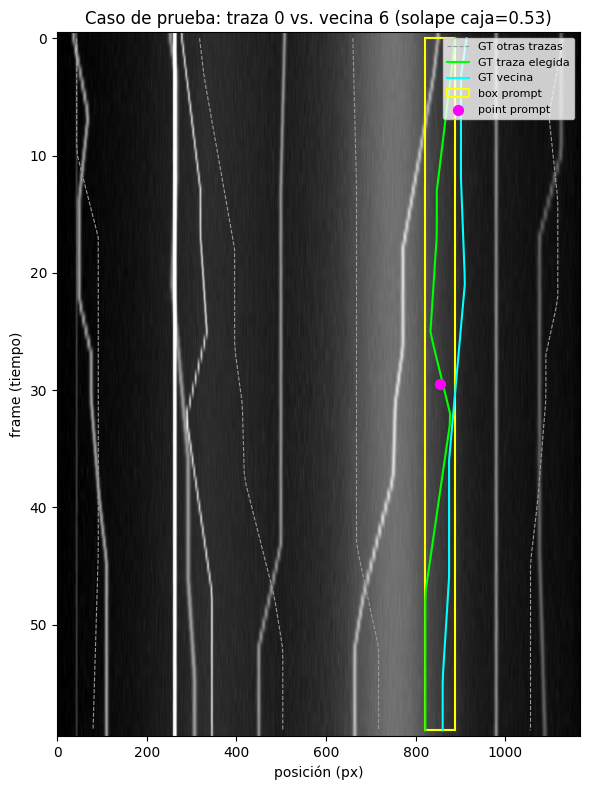

In [18]:
row = boxes_gt.loc[target_id]
# Convencion de imagen: x = columna = posicion, y = fila = frame (coincide con imshow/PIL, sin transponer).
box_prompt = [
    float(row.col_min),
    float(row.frame_min),
    float(row.col_max),
    float(row.frame_max),
]
point_prompt = [
    (box_prompt[0] + box_prompt[2]) / 2,
    (box_prompt[1] + box_prompt[3]) / 2,
]

print(f"Box prompt   (x1,y1,x2,y2): {[round(v, 1) for v in box_prompt]}")
print(f"Point prompt (x,y):         {[round(v, 1) for v in point_prompt]}")

fig, ax = plt.subplots(figsize=(6, 8))
ax.imshow(
    kymo,
    cmap="gray",
    aspect="auto",
    vmin=np.percentile(kymo, 1),
    vmax=np.percentile(kymo, 99.5),
)

# Todas las demas trazas moviles (no solo target/vecina) -- para no confundir "cerca del prompt"
# con "es la elegida o la vecina": una mascara puede seguir una tercera traza sin etiquetar.
for pid, g in movers.groupby("particle_id"):
    if pid in (target_id, neighbor_id):
        continue
    sub = g.sort_values("frame")
    ax.plot(
        sub["col"], sub["frame"], color="0.6", linewidth=0.8, linestyle="--", zorder=1
    )
ax.plot([], [], color="0.6", linewidth=0.8, linestyle="--", label="GT otras trazas")

for pid, color, label in [
    (target_id, "lime", "GT traza elegida"),
    (neighbor_id, "cyan", "GT vecina"),
]:
    sub = movers[movers["particle_id"] == pid].sort_values("frame")
    ax.plot(sub["col"], sub["frame"], color=color, linewidth=1.5, label=label, zorder=2)

ax.add_patch(
    Rectangle(
        (box_prompt[0], box_prompt[1]),
        box_prompt[2] - box_prompt[0],
        box_prompt[3] - box_prompt[1],
        edgecolor="yellow",
        facecolor="none",
        linewidth=1.5,
        label="box prompt",
    )
)
ax.scatter(
    [point_prompt[0]],
    [point_prompt[1]],
    color="magenta",
    s=50,
    zorder=5,
    label="point prompt",
)
ax.set_xlabel("posición (px)")
ax.set_ylabel("frame (tiempo)")
ax.legend(loc="upper right", fontsize=8)
ax.set_title(
    f"Caso de prueba: traza {target_id} vs. vecina {neighbor_id} (solape caja={overlap_frac:.2f})"
)
plt.tight_layout()
plt.show()

## 3. Cargar `Sam3TrackerModel` / `Sam3TrackerProcessor`

Mismo checkpoint ya cacheado por `03_roi_sintetico_sam3.ipynb` (`facebook/sam3`), distinta clase
(`Sam3TrackerModel` en vez de `Sam3Model`) porque es la que acepta prompts de punto. `dtype=torch.bfloat16`
sigue el mismo patrón que NB03; si da problemas en tu device, sacar el `dtype` y usar float32.


In [19]:
from transformers import Sam3TrackerModel, Sam3TrackerProcessor

MODEL_ID = "facebook/sam3"
processor_tracker = Sam3TrackerProcessor.from_pretrained(MODEL_ID)
model_tracker = (
    Sam3TrackerModel.from_pretrained(MODEL_ID, dtype=torch.bfloat16).to(device).eval()
)

n_params = sum(p.numel() for p in model_tracker.parameters()) / 1e6
print(f"Sam3TrackerModel cargado ({MODEL_ID}): {n_params:.1f}M parametros")

kymo_pil = Image.fromarray(norm_uint8(kymo)).convert("RGB")  # SAM3 espera RGB, ver NB03
print(f"Imagen PIL: {kymo_pil.size}")

[transformers] You are using a model of type `sam3_video` to instantiate a model of type `sam3_tracker`. This may be expected if you are loading a checkpoint that shares a subset of the architecture (e.g., loading a `sam2_video` checkpoint into `Sam2Model`), but is otherwise not supported and can yield errors. Please verify that the checkpoint is compatible with the model you are instantiating.


Loading weights:   0%|          | 0/685 [00:00<?, ?it/s]

Sam3TrackerModel cargado (facebook/sam3): 458.3M parametros
Imagen PIL: (1167, 60)


## 4. Baseline A — box-prompt


In [20]:
inputs_box = processor_tracker(
    images=kymo_pil,
    input_boxes=[[box_prompt]],  # [imagen][caja] -- una sola caja para esta prueba
    return_tensors="pt",
).to(device)

with torch.no_grad():
    out_box = model_tracker(**_to_bf16(inputs_box), multimask_output=False)

masks_box = processor_tracker.post_process_masks(
    out_box.pred_masks.float(), inputs_box["original_sizes"], binarize=True
)
mask_A = masks_box[0][0, 0].cpu().numpy()  # (H, W) bool
print(f"Baseline A (box-prompt): mascara {mask_A.shape}, {mask_A.sum()} px activos")

Baseline A (box-prompt): mascara (60, 1167), 2119 px activos


## 5. Baseline B — point-prompt

Mismo modelo, mismo checkpoint, el punto viene del centroide de la caja de arriba (celda de la
sección 2) en vez de la caja completa. `input_labels=1` marca el punto como foreground.


In [21]:
inputs_pt = processor_tracker(
    images=kymo_pil,
    input_points=[[[point_prompt]]],  # [imagen][objeto][punto] -> [x, y]
    input_labels=[[[1]]],  # 1 = foreground
    return_tensors="pt",
).to(device)

with torch.no_grad():
    out_pt = model_tracker(**_to_bf16(inputs_pt), multimask_output=False)

masks_pt = processor_tracker.post_process_masks(
    out_pt.pred_masks.float(), inputs_pt["original_sizes"], binarize=True
)
mask_B = masks_pt[0][0, 0].cpu().numpy()  # (H, W) bool
print(f"Baseline B (point-prompt): mascara {mask_B.shape}, {mask_B.sum()} px activos")

Baseline B (point-prompt): mascara (60, 1167), 26892 px activos


## 6. Comparar: visual + métricas cuantitativas

Además de mirar las máscaras, se calcula una máscara ground-truth por traza (dilatando la
polilínea por `size_um/pixel_scale_um`, mismo criterio que el Paso 3.2 de la guía) para medir:
`recall`/`precision` contra la traza elegida, y **`leakage_into_neighbor`** — la fracción de la
máscara predicha que cae dentro de la traza vecina. `leakage_into_neighbor` alto es exactamente
el fallo que este notebook existe para detectar.


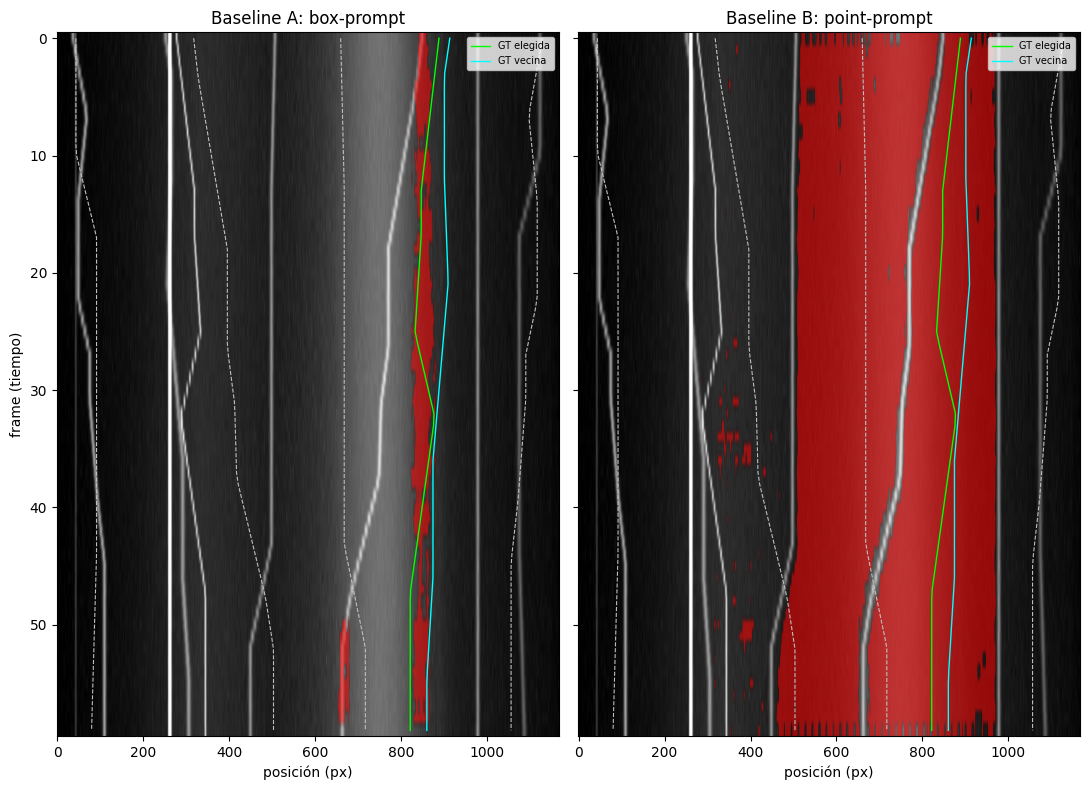

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(11, 8), sharey=True)
for ax, mask, name in zip(
    axes, [mask_A, mask_B], ["Baseline A: box-prompt", "Baseline B: point-prompt"]
):
    ax.imshow(
        kymo,
        cmap="gray",
        aspect="auto",
        vmin=np.percentile(kymo, 1),
        vmax=np.percentile(kymo, 99.5),
    )
    ax.imshow(np.ma.masked_where(~mask, mask), cmap="autumn", alpha=0.55, aspect="auto")
    # Todas las trazas GT, no solo target/vecina -- para poder identificar si la mascara
    # predicha en realidad sigue una tercera traza sin etiquetar.
    for pid, g in movers.groupby("particle_id"):
        if pid in (target_id, neighbor_id):
            continue
        sub = g.sort_values("frame")
        ax.plot(
            sub["col"],
            sub["frame"],
            color="0.75",
            linewidth=0.8,
            linestyle="--",
            zorder=1,
        )
    for pid, color, label in [
        (target_id, "lime", "GT elegida"),
        (neighbor_id, "cyan", "GT vecina"),
    ]:
        sub = movers[movers["particle_id"] == pid].sort_values("frame")
        ax.plot(
            sub["col"], sub["frame"], color=color, linewidth=1, label=label, zorder=2
        )
    ax.set_title(name)
    ax.set_xlabel("posición (px)")
    ax.legend(fontsize=7, loc="upper right")
axes[0].set_ylabel("frame (tiempo)")
plt.tight_layout()
plt.show()

In [23]:
from skimage.draw import line as skline
from skimage.morphology import disk
from scipy.ndimage import binary_dilation


def gt_mask_for_particle(pid, shape, movers_df, pixel_scale_um):
    """Rasteriza la polilinea GT de una particula y la dilata por su ancho renderizado real."""
    sub = movers_df[movers_df["particle_id"] == pid].sort_values("frame")
    mask = np.zeros(shape, dtype=bool)
    rows = sub["frame"].to_numpy()
    cols = sub["col"].to_numpy()
    for k in range(len(sub) - 1):
        rr, cc = skline(
            int(rows[k]), int(round(cols[k])), int(rows[k + 1]), int(round(cols[k + 1]))
        )
        valid = (rr >= 0) & (rr < shape[0]) & (cc >= 0) & (cc < shape[1])
        mask[rr[valid], cc[valid]] = True
    width_px = max(int(round(sub["size_um"].mean() / pixel_scale_um)), 1)
    return binary_dilation(mask, structure=disk(width_px))


gt_target_mask = gt_mask_for_particle(target_id, kymo.shape, movers, pixel_scale_um)
gt_neighbor_mask = gt_mask_for_particle(neighbor_id, kymo.shape, movers, pixel_scale_um)


def evaluate_mask(pred_mask, gt_target_mask, gt_neighbor_mask):
    pred = pred_mask.astype(bool)
    recall = (pred & gt_target_mask).sum() / max(gt_target_mask.sum(), 1)
    precision = (pred & gt_target_mask).sum() / max(pred.sum(), 1)
    leakage = (pred & gt_neighbor_mask).sum() / max(pred.sum(), 1)
    area_frac = (
        pred.sum() / pred.size
    )  # guarda contra mascaras degeneradas -- ver roi_detect.py
    return {
        "recall": round(float(recall), 3),
        "precision": round(float(precision), 3),
        "leakage_into_neighbor": round(float(leakage), 3),
        "area_frac": round(float(area_frac), 4),
    }


metrics_A = evaluate_mask(mask_A, gt_target_mask, gt_neighbor_mask)
metrics_B = evaluate_mask(mask_B, gt_target_mask, gt_neighbor_mask)

print("Baseline A (box-prompt):  ", metrics_A)
print("Baseline B (point-prompt):", metrics_B)

Baseline A (box-prompt):   {'recall': 0.572, 'precision': 0.22, 'leakage_into_neighbor': 0.032, 'area_frac': 0.0303}
Baseline B (point-prompt): {'recall': 0.996, 'precision': 0.03, 'leakage_into_neighbor': 0.024, 'area_frac': 0.3841}


### 6b. ¿La máscara sigue una identidad estable, o "salta" entre partículas reales?

`leakage_into_neighbor` sólo mide solape contra **una** vecina nombrada — no detecta si la
máscara predicha, a lo largo de su propio recorrido, se acerca más a una partícula real distinta
en distintos tramos. Para una traza diagonal larga en una escena densa, dos partículas reales
distintas pueden pasar muy cerca (sin llegar a "cruzarse" en el sentido de solape de cajas) en
algún tramo — si SAM seguye continuidad visual local en vez de identidad de objeto, la máscara
puede "cambiar de dueño" ahí sin que el pixel-count o el leakage contra una sola vecina lo
capturen. Se verificó esto directamente (no se asume): para cada fila con píxeles activos, se
busca la partícula GT cuya columna es más cercana a la columna de la máscara en esa fila, y se
cuenta cuántas veces cambia esa partícula "más cercana" a lo largo del recorrido.


In [24]:
def nearest_particle_per_row(mask, movers_df, n_frames):
    """Para cada fila con pixeles activos: (particle_id GT mas cercano, distancia en px)."""
    trace = {}
    for f in range(n_frames):
        row_px = np.where(mask[f])[0]
        if len(row_px) == 0:
            continue
        mcol = row_px.mean()
        best_pid, best_d = None, None
        for pid, g in movers_df.groupby("particle_id"):
            gf = g[g.frame == f]
            if len(gf) == 0:
                continue
            d = abs(gf["col"].iloc[0] - mcol)
            if best_d is None or d < best_d:
                best_pid, best_d = pid, d
        trace[f] = (best_pid, best_d)
    return trace


def summarize_identity(trace, own_id):
    ids = [pid for pid, _ in trace.values()]
    switches = sum(1 for a, b in zip(ids, ids[1:]) if a != b)
    frac_own = sum(1 for i in ids if i == own_id) / max(len(ids), 1)
    return {
        "particle_ids_mas_cercana_en_algun_punto": sorted(set(ids)),
        "cambios_de_identidad": switches,
        "filas_con_mascara": len(ids),
        "fraccion_de_filas_donde_la_mas_cercana_es_la_elegida": round(frac_own, 2),
    }


trace_A = nearest_particle_per_row(mask_A, movers, kymo.shape[0])
trace_B = nearest_particle_per_row(mask_B, movers, kymo.shape[0])

print("Baseline A (box-prompt):  ", summarize_identity(trace_A, target_id))
print("Baseline B (point-prompt):", summarize_identity(trace_B, target_id))

Baseline A (box-prompt):   {'particle_ids_mas_cercana_en_algun_punto': [0, 2, 6], 'cambios_de_identidad': 6, 'filas_con_mascara': 59, 'fraccion_de_filas_donde_la_mas_cercana_es_la_elegida': 0.9}
Baseline B (point-prompt): {'particle_ids_mas_cercana_en_algun_punto': [2], 'cambios_de_identidad': 0, 'filas_con_mascara': 60, 'fraccion_de_filas_donde_la_mas_cercana_es_la_elegida': 0.0}


### 6c. ¿Ayuda ubicar el punto en el pico de brillo real, en vez del centro geométrico de la caja?

El punto de Baseline B es el centro geométrico de la caja — un supuesto geométrico (la traza
corre "esquina a esquina"), no una lectura del kymógrafo real. Como la partícula es una franja
brillante, el centro geométrico podría no coincidir con el píxel de mayor brillo real en esa
zona (más aún si la traza tiene pausas/cambios de dirección, que no son rectas perfectas). Se
prueba acá, sin asumir el resultado: buscar el pico de brillo real en una ventana local alrededor
del punto original (ventana pequeña a propósito — buscar en toda la imagen encontraría el pixel
más brillante de _cualquier_ partícula, no necesariamente el de la elegida).


In [25]:
def brightness_point_near(kymo, approx_xy, col_window=10, row_window=2):
    """Punto de mayor intensidad real en una ventana local alrededor de approx_xy=(col,row)."""
    col0, row0 = int(round(approx_xy[0])), int(round(approx_xy[1]))
    r_lo, r_hi = max(row0 - row_window, 0), min(row0 + row_window + 1, kymo.shape[0])
    c_lo, c_hi = max(col0 - col_window, 0), min(col0 + col_window + 1, kymo.shape[1])
    patch = kymo[r_lo:r_hi, c_lo:c_hi].astype(np.float32)
    ridx, cidx = np.unravel_index(np.argmax(patch), patch.shape)
    return [float(c_lo + cidx), float(r_lo + ridx)]


point_prompt_bright = brightness_point_near(kymo, point_prompt)
print(
    "Point prompt (centro geometrico de la caja):", [round(v, 1) for v in point_prompt]
)
print(
    "Point prompt (pico de brillo local):         ",
    [round(v, 1) for v in point_prompt_bright],
)
print(
    "Distancia entre ambos:",
    round(
        float(np.hypot(*(np.array(point_prompt) - np.array(point_prompt_bright)))), 1
    ),
    "px",
)

Point prompt (centro geometrico de la caja): [855.0, 29.5]
Point prompt (pico de brillo local):          [846.0, 32.0]
Distancia entre ambos: 9.3 px


In [26]:
inputs_pt2 = processor_tracker(
    images=kymo_pil,
    input_points=[[[point_prompt_bright]]],
    input_labels=[[[1]]],
    return_tensors="pt",
).to(device)

with torch.no_grad():
    out_pt2 = model_tracker(**_to_bf16(inputs_pt2), multimask_output=False)

masks_pt2 = processor_tracker.post_process_masks(
    out_pt2.pred_masks.float(), inputs_pt2["original_sizes"], binarize=True
)
mask_B2 = masks_pt2[0][0, 0].cpu().numpy()
print(
    f"Baseline B (punto en pico de brillo): mascara {mask_B2.shape}, {mask_B2.sum()} px activos"
)

metrics_B2 = evaluate_mask(mask_B2, gt_target_mask, gt_neighbor_mask)
identity_B2 = summarize_identity(
    nearest_particle_per_row(mask_B2, movers, kymo.shape[0]), target_id
)

print()
print("Comparación del punto (centro de caja) vs. (pico de brillo local):")
print("  metricas   B (centro):      ", metrics_B)
print("  metricas   B (brillo):      ", metrics_B2)
print("  identidad  B (centro):      ", summarize_identity(trace_B, target_id))
print("  identidad  B (brillo):      ", identity_B2)

Baseline B (punto en pico de brillo): mascara (60, 1167), 49032 px activos

Comparación del punto (centro de caja) vs. (pico de brillo local):
  metricas   B (centro):       {'recall': 0.996, 'precision': 0.03, 'leakage_into_neighbor': 0.024, 'area_frac': 0.3841}
  metricas   B (brillo):       {'recall': 0.999, 'precision': 0.017, 'leakage_into_neighbor': 0.014, 'area_frac': 0.7003}
  identidad  B (centro):       {'particle_ids_mas_cercana_en_algun_punto': [2], 'cambios_de_identidad': 0, 'filas_con_mascara': 60, 'fraccion_de_filas_donde_la_mas_cercana_es_la_elegida': 0.0}
  identidad  B (brillo):       {'particle_ids_mas_cercana_en_algun_punto': [2], 'cambios_de_identidad': 0, 'filas_con_mascara': 60, 'fraccion_de_filas_donde_la_mas_cercana_es_la_elegida': 0.0}


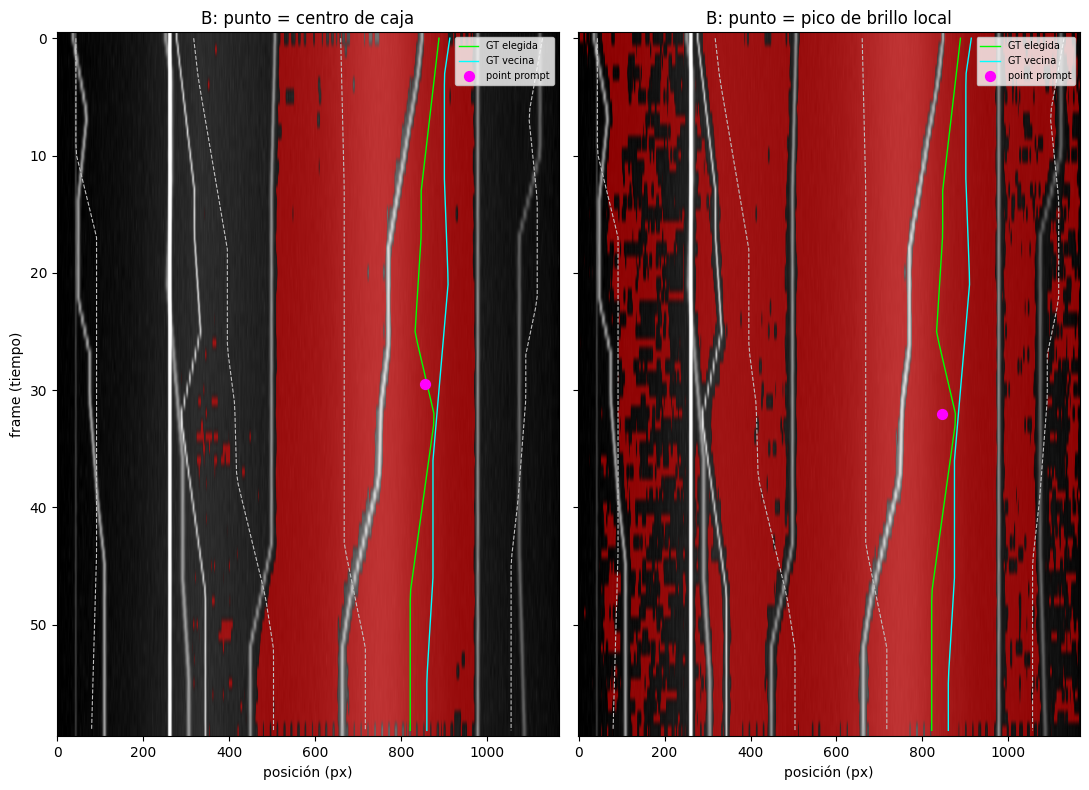

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(11, 8), sharey=True)
for ax, mask, pt, name in zip(
    axes,
    [mask_B, mask_B2],
    [point_prompt, point_prompt_bright],
    ["B: punto = centro de caja", "B: punto = pico de brillo local"],
):
    ax.imshow(
        kymo,
        cmap="gray",
        aspect="auto",
        vmin=np.percentile(kymo, 1),
        vmax=np.percentile(kymo, 99.5),
    )
    ax.imshow(np.ma.masked_where(~mask, mask), cmap="autumn", alpha=0.55, aspect="auto")
    for pid, g in movers.groupby("particle_id"):
        if pid in (target_id, neighbor_id):
            continue
        sub = g.sort_values("frame")
        ax.plot(
            sub["col"],
            sub["frame"],
            color="0.75",
            linewidth=0.8,
            linestyle="--",
            zorder=1,
        )
    for pid, color, label in [
        (target_id, "lime", "GT elegida"),
        (neighbor_id, "cyan", "GT vecina"),
    ]:
        sub = movers[movers["particle_id"] == pid].sort_values("frame")
        ax.plot(
            sub["col"], sub["frame"], color=color, linewidth=1, label=label, zorder=2
        )
    ax.scatter([pt[0]], [pt[1]], color="magenta", s=50, zorder=5, label="point prompt")
    ax.set_title(name)
    ax.set_xlabel("posición (px)")
    ax.legend(fontsize=7, loc="upper right")
axes[0].set_ylabel("frame (tiempo)")
plt.tight_layout()
plt.show()

### 6d. ¿Ayuda batchear las 3 cajas juntas con `apply_non_overlapping_constraints`?

Hasta acá cada caja se mandó en una llamada **independiente** a SAM3 — el modelo nunca supo que
existían las otras cajas, así que dos máscaras predichas por separado pueden reclamar los mismos
píxeles sin que nada lo evite. `Sam3TrackerProcessor.post_process_masks` tiene un parámetro
`apply_non_overlapping_constraints` (verificado en el código fuente, no en la doc): hace un
argmax por píxel entre todas las máscaras del batch y sólo deja el píxel a la de mayor score ahí
— el mismo principio que `resolve_overlaps` de `tracking.py` en KymoButler. **Ojo**: sólo hace
algo si las cajas van en el **mismo batch** (`input_boxes=[[caja1, caja2, caja3]]`, una sola
llamada) — llamado por separado (como arriba) es un no-op, verificado directamente.

Se prueba con las 3 partículas realmente involucradas en este caso: la elegida (2), la vecina
(6), y la tercera que apareció en la deriva de identidad de la sección 6b/6c (partícula 3).


In [28]:
third_id = 3  # aparecio en la deriva de identidad de mask_B (6b/6c)
ids_batch = [target_id, neighbor_id, third_id]

boxes_batch = []
for pid in ids_batch:
    r = boxes_gt.loc[pid]
    boxes_batch.append(
        [float(r.col_min), float(r.frame_min), float(r.col_max), float(r.frame_max)]
    )

print("Cajas batcheadas (target, vecina, tercera):")
for pid, b in zip(ids_batch, boxes_batch):
    print(f"  particle_id={pid}: {[round(v, 1) for v in b]}")

inputs_batch = processor_tracker(
    images=kymo_pil,
    input_boxes=[boxes_batch],  # [imagen][caja1, caja2, caja3] -- UNA sola llamada
    return_tensors="pt",
).to(device)

with torch.no_grad():
    out_batch = model_tracker(**_to_bf16(inputs_batch), multimask_output=False)

print("pred_masks shape:", out_batch.pred_masks.shape)

KeyError: 3

In [ ]:
masks_no_constraint = processor_tracker.post_process_masks(
    out_batch.pred_masks.float(),
    inputs_batch["original_sizes"],
    binarize=True,
    apply_non_overlapping_constraints=False,
)[
    0
]  # (3, 1, H, W)
masks_constraint = processor_tracker.post_process_masks(
    out_batch.pred_masks.float(),
    inputs_batch["original_sizes"],
    binarize=True,
    apply_non_overlapping_constraints=True,
)[
    0
]  # (3, 1, H, W)

masks_no_np = masks_no_constraint[:, 0].cpu().numpy()  # (3, H, W)
masks_yes_np = masks_constraint[:, 0].cpu().numpy()

print("Solape de a pares SIN apply_non_overlapping_constraints (px compartidos):")
for i in range(3):
    for j in range(i + 1, 3):
        shared = int((masks_no_np[i] & masks_no_np[j]).sum())
        print(f"  particle_id {ids_batch[i]} vs {ids_batch[j]}: {shared} px")

print("Solape de a pares CON apply_non_overlapping_constraints (px compartidos):")
for i in range(3):
    for j in range(i + 1, 3):
        shared = int((masks_yes_np[i] & masks_yes_np[j]).sum())
        print(f"  particle_id {ids_batch[i]} vs {ids_batch[j]}: {shared} px")

Solape de a pares SIN apply_non_overlapping_constraints (px compartidos):
  particle_id 2 vs 6: 405 px
  particle_id 2 vs 3: 0 px
  particle_id 6 vs 3: 1 px
Solape de a pares CON apply_non_overlapping_constraints (px compartidos):
  particle_id 2 vs 6: 0 px
  particle_id 2 vs 3: 0 px
  particle_id 6 vs 3: 0 px


In [ ]:
# La mascara del target es siempre el indice 0 (orden de ids_batch)
mask_target_no = masks_no_np[0]
mask_target_yes = masks_yes_np[0]

print("Mascara del target (particle_id=%d):" % target_id)
print(
    "  SIN constraint:",
    mask_target_no.sum(),
    "px --",
    evaluate_mask(mask_target_no, gt_target_mask, gt_neighbor_mask),
)
print(
    "  CON constraint:",
    mask_target_yes.sum(),
    "px --",
    evaluate_mask(mask_target_yes, gt_target_mask, gt_neighbor_mask),
)
print()
print(
    "  identidad SIN constraint:",
    summarize_identity(
        nearest_particle_per_row(mask_target_no, movers, kymo.shape[0]), target_id
    ),
)
print(
    "  identidad CON constraint:",
    summarize_identity(
        nearest_particle_per_row(mask_target_yes, movers, kymo.shape[0]), target_id
    ),
)

Mascara del target (particle_id=2):
  SIN constraint: 5116 px -- {'recall': 0.351, 'precision': 0.098, 'leakage_into_neighbor': 0.066, 'area_frac': 0.1234}
  CON constraint: 5012 px -- {'recall': 0.348, 'precision': 0.099, 'leakage_into_neighbor': 0.067, 'area_frac': 0.1209}

  identidad SIN constraint: {'particle_ids_mas_cercana_en_algun_punto': [2, 6], 'cambios_de_identidad': 2, 'filas_con_mascara': 60, 'fraccion_de_filas_donde_la_mas_cercana_es_la_elegida': 0.2}
  identidad CON constraint: {'particle_ids_mas_cercana_en_algun_punto': [2, 6], 'cambios_de_identidad': 2, 'filas_con_mascara': 60, 'fraccion_de_filas_donde_la_mas_cercana_es_la_elegida': 0.2}


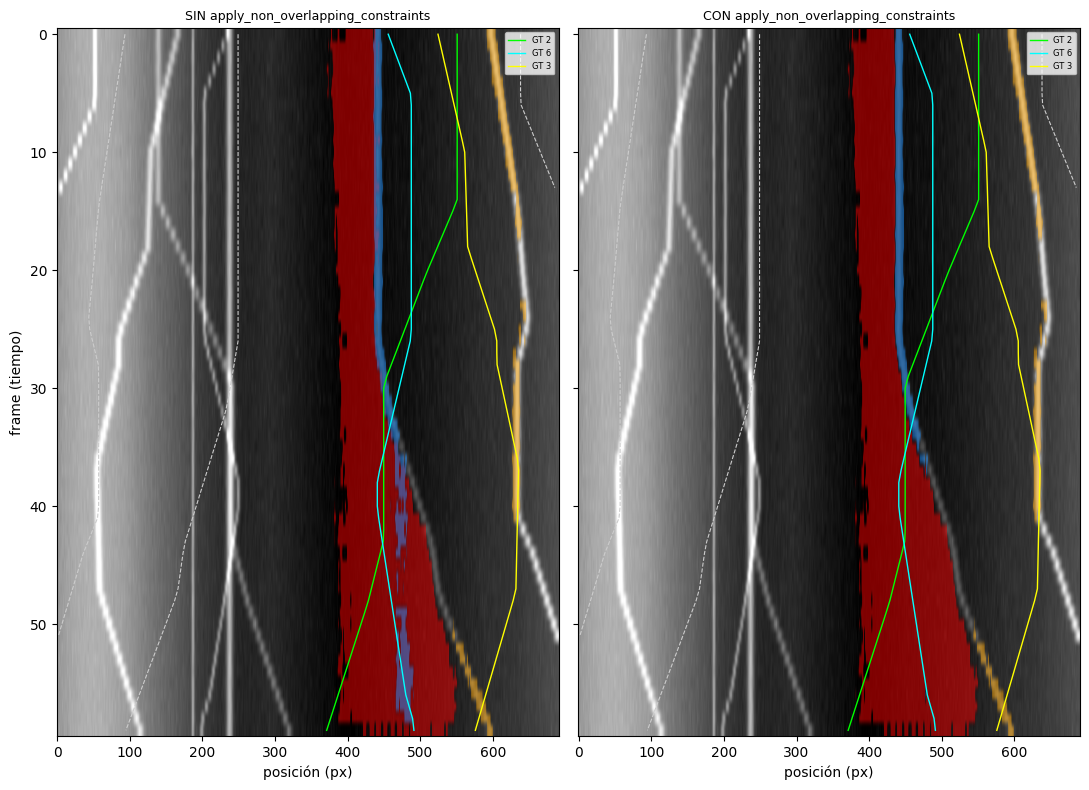

In [ ]:
colors3 = ["red", "dodgerblue", "orange"]
fig, axes = plt.subplots(1, 2, figsize=(11, 8), sharey=True)
for ax, masks3, name in zip(
    axes,
    [masks_no_np, masks_yes_np],
    ["SIN apply_non_overlapping_constraints", "CON apply_non_overlapping_constraints"],
):
    ax.imshow(
        kymo,
        cmap="gray",
        aspect="auto",
        vmin=np.percentile(kymo, 1),
        vmax=np.percentile(kymo, 99.5),
    )
    for k, (pid, mask) in enumerate(zip(ids_batch, masks3)):
        ax.imshow(
            np.ma.masked_where(~mask, mask),
            cmap=plt.matplotlib.colors.ListedColormap([colors3[k]]),
            alpha=0.5,
            aspect="auto",
        )
    for pid, g in movers.groupby("particle_id"):
        if pid in ids_batch:
            continue
        sub = g.sort_values("frame")
        ax.plot(
            sub["col"],
            sub["frame"],
            color="0.8",
            linewidth=0.8,
            linestyle="--",
            zorder=1,
        )
    for pid, color in zip(ids_batch, ["lime", "cyan", "yellow"]):
        sub = movers[movers["particle_id"] == pid].sort_values("frame")
        ax.plot(
            sub["col"],
            sub["frame"],
            color=color,
            linewidth=1,
            label=f"GT {pid}",
            zorder=2,
        )
    ax.set_title(name, fontsize=9)
    ax.set_xlabel("posición (px)")
    ax.legend(fontsize=6, loc="upper right")
axes[0].set_ylabel("frame (tiempo)")
plt.tight_layout()
plt.show()

### 6e. ¿Ayuda des-distorsionar el aspect ratio del kymógrafo antes de promptear?

El kymógrafo es de **60×691** (una tira de aspecto 11.5:1). El `Sam3TrackerProcessor` reescala
_todo_ a un cuadrado de **1008×1008** (verificado directamente: `image_processor.size =
{height:1008, width:1008}`, `do_pad=None` → estira, no rellena con padding). Eso estira el eje
**tiempo ~16.8×** (60→1008) mientras el eje **posición se estira sólo ~1.46×** (691→1008): las
diagonales que se ven en el plot se vuelven **casi verticales y muy juntas** en la imagen que el
encoder realmente procesa — que es exactamente la franja vertical de Baseline A y el deslizamiento
del punto en Baseline B.

Antes de aceptar la conclusión de la sección 7 ("es una limitación de fondo del modelo congelado"),
hay que **descartar este confound de preprocesamiento**: si el mal resultado se debiera a la
distorsión del aspect ratio y no a SAM, llevar el kymógrafo a ~cuadrado _antes_ de pasarlo al
modelo (upsamplear el eje tiempo 60→691, dejar posición intacta) debería mejorar las máscaras —
el reescalado interno de SAM pasa a ser isotrópico (~1.46× en ambos ejes) y las diagonales
conservan su pendiente real.

Se corren los **mismos** prompts (box y punto) sobre el kymógrafo des-distorsionado, se baja la
máscara de vuelta al espacio original (60×691) con max-pool por filas, y se reusan `evaluate_mask`
y el diagnóstico de identidad de 6b — así el "antes vs. después" es directamente comparable.


In [ ]:
from skimage.transform import resize as sk_resize

# El Sam3TrackerProcessor reescala TODO a 1008x1008 sin padding (verificado:
# image_processor.size = {height:1008, width:1008}, do_pad=None). Con un kymografo 60x691 eso
# estira el eje tiempo ~16.8x (60->1008) y el de posicion solo ~1.46x (691->1008) -> las
# diagonales se vuelven casi verticales. Llevar el kymografo a ~cuadrado (tiempo 60 -> 691,
# posicion intacta) ANTES de pasarlo al modelo hace isotropico ese reescalado interno (~1.46x
# en ambos ejes) y las diagonales conservan su pendiente real.
H0, W0 = kymo.shape  # (60, 691)
H1 = W0  # tiempo upsampleado a 691 -> imagen 691x691
sy = H1 / H0  # factor de escala del eje tiempo (~11.5x)

kymo_sq = sk_resize(kymo.astype(np.float32), (H1, W0), order=1, anti_aliasing=True)
kymo_sq_pil = Image.fromarray(norm_uint8(kymo_sq)).convert("RGB")
# Los prompts estan en coords del kymografo original (x=col, y=frame). Solo cambia el eje y.
box_prompt_sq = [box_prompt[0], box_prompt[1] * sy, box_prompt[2], box_prompt[3] * sy]
point_prompt_sq = [point_prompt[0], point_prompt[1] * sy]
print(f"Des-distorsion: {kymo.shape} -> {kymo_sq.shape}  (sy={sy:.2f})")


def _run_sam(image_pil, *, box=None, point=None):
    """Corre Sam3TrackerModel con un box o un punto; devuelve la mascara (H, W) bool."""
    if box is not None:
        inp = processor_tracker(
            images=image_pil, input_boxes=[[box]], return_tensors="pt"
        ).to(device)
    else:
        inp = processor_tracker(
            images=image_pil,
            input_points=[[[point]]],
            input_labels=[[[1]]],
            return_tensors="pt",
        ).to(device)
    with torch.no_grad():
        out = model_tracker(**_to_bf16(inp), multimask_output=False)
    m = processor_tracker.post_process_masks(
        out.pred_masks.float(), inp["original_sizes"], binarize=True
    )
    return m[0][0, 0].cpu().numpy()


def _downsample_mask(mask_sq):
    """Baja la mascara (H1, W0) al espacio original (H0, W0) con max-pool por filas, para poder
    reusar evaluate_mask / nearest_particle_per_row (que trabajan en el espacio original).
    """
    out = np.zeros((H0, W0), dtype=bool)
    for f in range(H0):
        r_lo, r_hi = int(round(f * sy)), int(round((f + 1) * sy))
        out[f] = mask_sq[r_lo:r_hi].any(axis=0)
    return out


mask_A_sq = _downsample_mask(_run_sam(kymo_sq_pil, box=box_prompt_sq))
mask_B_sq = _downsample_mask(_run_sam(kymo_sq_pil, point=point_prompt_sq))

print("\n--- Metricas: original (distorsionado) vs. des-distorsionado ---")
print("A box   original:", evaluate_mask(mask_A, gt_target_mask, gt_neighbor_mask))
print("A box   sq      :", evaluate_mask(mask_A_sq, gt_target_mask, gt_neighbor_mask))
print("B point original:", evaluate_mask(mask_B, gt_target_mask, gt_neighbor_mask))
print("B point sq      :", evaluate_mask(mask_B_sq, gt_target_mask, gt_neighbor_mask))
print("\n--- Identidad (6b): original vs. des-distorsionado ---")
print(
    "A original:",
    summarize_identity(nearest_particle_per_row(mask_A, movers, H0), target_id),
)
print(
    "A sq      :",
    summarize_identity(nearest_particle_per_row(mask_A_sq, movers, H0), target_id),
)
print(
    "B original:",
    summarize_identity(nearest_particle_per_row(mask_B, movers, H0), target_id),
)
print(
    "B sq      :",
    summarize_identity(nearest_particle_per_row(mask_B_sq, movers, H0), target_id),
)

In [ ]:
def _plot_mask(ax, mask, title):
    ax.imshow(
        kymo,
        cmap="gray",
        aspect="auto",
        vmin=np.percentile(kymo, 1),
        vmax=np.percentile(kymo, 99.5),
    )
    ax.imshow(np.ma.masked_where(~mask, mask), cmap="autumn", alpha=0.55, aspect="auto")
    for pid, g in movers.groupby("particle_id"):
        if pid in (target_id, neighbor_id):
            continue
        sub = g.sort_values("frame")
        ax.plot(
            sub["col"],
            sub["frame"],
            color="0.75",
            linewidth=0.8,
            linestyle="--",
            zorder=1,
        )
    for pid, color, label in [
        (target_id, "lime", "GT elegida"),
        (neighbor_id, "cyan", "GT vecina"),
    ]:
        sub = movers[movers["particle_id"] == pid].sort_values("frame")
        ax.plot(
            sub["col"], sub["frame"], color=color, linewidth=1, label=label, zorder=2
        )
    ax.set_title(title, fontsize=9)
    ax.legend(fontsize=6, loc="upper right")


fig, axes = plt.subplots(2, 2, figsize=(11, 11), sharex=True, sharey=True)
_plot_mask(axes[0, 0], mask_A, "A box — original (distorsionado)")
_plot_mask(axes[0, 1], mask_A_sq, "A box — des-distorsionado (~cuadrado)")
_plot_mask(axes[1, 0], mask_B, "B point — original (distorsionado)")
_plot_mask(axes[1, 1], mask_B_sq, "B point — des-distorsionado (~cuadrado)")
for ax in axes[:, 0]:
    ax.set_ylabel("frame (tiempo)")
for ax in axes[1, :]:
    ax.set_xlabel("posición (px)")
plt.tight_layout()
plt.show()

### 6f. Barrido multi-seed: ¿el fracaso del peor caso es consistente, o suerte de un seed?

La sección 7 pedía correr 2–3 seeds más antes de tratar el resultado de un solo seed como
representativo. Acá se automatiza: para cada seed se regenera la escena densa, se elige de nuevo
el **peor caso** (par de trazas con más solape de cajas) y se corren los mismos box- y
point-prompt. Se reporta por seed: `overlap` (solape del peor par), `recall`, `leak`
(`leakage_into_neighbor`), `switch` (cambios de identidad de 6b) y **`own`** (fracción de filas
donde la máscara más cercana es la traza elegida — la métrica de _fidelidad_, más informativa que
`leak` sola).


In [ ]:
import copy


def _prep_scene(cfg, seed):
    """Regenera una escena y devuelve (kymo, movers, boxes_gt, kymo_pil) para ese seed."""
    c = copy.deepcopy(cfg)
    c["general"]["seed"] = seed
    r = generate(c, seed=seed)
    k = r.kymograph
    mv = r.positions[r.positions["type"] != "static"].copy()
    mv["col"] = mv["pos_um"] / pixel_scale_um
    bg = mv.groupby("particle_id").agg(
        frame_min=("frame", "min"),
        frame_max=("frame", "max"),
        col_min=("col", "min"),
        col_max=("col", "max"),
        type=("type", "first"),
    )
    return k, mv, bg, Image.fromarray(norm_uint8(k)).convert("RGB")


def _worst_pair(bg):
    """Par de trazas cuyas cajas mas se solapan (el 'peor caso' de la seccion 2)."""
    best = None
    for i, j in itertools.combinations(bg.index, 2):
        frac = max(
            box_overlap_frac(bg.loc[i], bg.loc[j]),
            box_overlap_frac(bg.loc[j], bg.loc[i]),
        )
        if best is None or frac > best[2]:
            best = (i, j, frac)
    return best


SEEDS = [123, 7, 42, 2024]  # agregar mas seeds y re-correr para robustecer la tabla
rows = []
for s in SEEDS:
    k, mv, bg, pil = _prep_scene(CONFIG, s)
    if len(bg) < 2:
        print(f"seed {s}: <2 trazas moviles, salteado")
        continue
    tid, nid, ov = _worst_pair(bg)
    r = bg.loc[tid]
    box = [float(r.col_min), float(r.frame_min), float(r.col_max), float(r.frame_max)]
    pt = [(box[0] + box[2]) / 2, (box[1] + box[3]) / 2]
    mA, mB = _run_sam(pil, box=box), _run_sam(pil, point=pt)
    gt_t = gt_mask_for_particle(tid, k.shape, mv, pixel_scale_um)
    gt_n = gt_mask_for_particle(nid, k.shape, mv, pixel_scale_um)
    eA, eB = evaluate_mask(mA, gt_t, gt_n), evaluate_mask(mB, gt_t, gt_n)
    iA = summarize_identity(nearest_particle_per_row(mA, mv, k.shape[0]), tid)
    iB = summarize_identity(nearest_particle_per_row(mB, mv, k.shape[0]), tid)
    rows.append(
        {
            "seed": s,
            "overlap": round(ov, 2),
            "A_recall": eA["recall"],
            "A_leak": eA["leakage_into_neighbor"],
            "A_switch": iA["cambios_de_identidad"],
            "A_own": iA["fraccion_de_filas_donde_la_mas_cercana_es_la_elegida"],
            "B_recall": eB["recall"],
            "B_leak": eB["leakage_into_neighbor"],
            "B_switch": iB["cambios_de_identidad"],
            "B_own": iB["fraccion_de_filas_donde_la_mas_cercana_es_la_elegida"],
        }
    )

sweep = pd.DataFrame(rows).set_index("seed")
print(sweep.to_string())

### 6g. La prueba decisiva: ¿SAM segmenta bien una traza AISLADA (sin vecina)?

Hasta acá todo se probó sobre el _peor_ caso (trazas que se solapan/cruzan). Falta la pregunta que
decide la estrategia: cuando **no** hay ambigüedad — una traza sola, sin vecina cerca — ¿SAM la
segmenta limpio? La respuesta bifurca todo el enfoque:

- **Si SAM es fiel a una traza aislada** (0 cambios de identidad, `own`≈1.0) → el problema de
  identidad es _específicamente_ de densidad/cruces, no una limitación general de SAM. Alcanzaría
  con que el pipeline **no le dé cruces** (detectar/partir/marcar cruces, Paso 4.7 de la guía),
  mucho más barato que fine-tunear.
- **Si falla incluso aislada** → el modelo congelado es inadecuado de raíz y hay que entrenar.

Se genera una escena **sparse** (1 static + 1 anterógrada + 1 retrógrada) y, entre varios seeds, se
toma la que tiene las 2 trazas móviles **más separadas** (`overlap` mínimo), para que el test sea
genuinamente "sin vecina". Target = la traza de mayor recorrido en posición.


In [ ]:
SPARSE_CONFIG = copy.deepcopy(CONFIG)
SPARSE_CONFIG["particles"]["type_counts"] = {
    "static": 1,
    "anterograde": 1,
    "retrograde": 1,
    "pure_anterograde": 0,
    "pure_retrograde": 0,
    "bidirectional": 0,
}

# entre varios seeds, la escena sparse cuyas 2 trazas moviles esten MAS separadas (overlap minimo)
best_iso = None
for s in range(20):
    k, mv, bg, pil = _prep_scene(SPARSE_CONFIG, s)
    if len(bg) < 2:
        continue
    _, _, ov = _worst_pair(bg)
    if best_iso is None or ov < best_iso[0]:
        best_iso = (ov, s, k, mv, bg, pil)

ov_iso, seed_iso, kymo_iso, movers_iso, bg_iso, pil_iso = best_iso
target_iso = (
    bg_iso["col_max"] - bg_iso["col_min"]
).idxmax()  # mayor recorrido en posicion
neighbor_iso = [p for p in bg_iso.index if p != target_iso][0]
print(
    f"Escena sparse: seed={seed_iso}  overlap peor-par={ov_iso:.2f}  "
    f"target={target_iso}  neighbor={neighbor_iso}"
)

r = bg_iso.loc[target_iso]
box_iso = [float(r.col_min), float(r.frame_min), float(r.col_max), float(r.frame_max)]
point_iso = [(box_iso[0] + box_iso[2]) / 2, (box_iso[1] + box_iso[3]) / 2]
mask_A_iso = _run_sam(pil_iso, box=box_iso)
mask_B_iso = _run_sam(pil_iso, point=point_iso)

gt_t_iso = gt_mask_for_particle(target_iso, kymo_iso.shape, movers_iso, pixel_scale_um)
gt_n_iso = gt_mask_for_particle(
    neighbor_iso, kymo_iso.shape, movers_iso, pixel_scale_um
)
print("\nA box   :", evaluate_mask(mask_A_iso, gt_t_iso, gt_n_iso))
print(
    "          ",
    summarize_identity(
        nearest_particle_per_row(mask_A_iso, movers_iso, kymo_iso.shape[0]), target_iso
    ),
)
print("B point :", evaluate_mask(mask_B_iso, gt_t_iso, gt_n_iso))
print(
    "          ",
    summarize_identity(
        nearest_particle_per_row(mask_B_iso, movers_iso, kymo_iso.shape[0]), target_iso
    ),
)

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(11, 6), sharey=True)
for ax, mask, name in zip(
    axes,
    [mask_A_iso, mask_B_iso],
    ["Aislada -- A box-prompt", "Aislada -- B point-prompt"],
):
    ax.imshow(
        kymo_iso,
        cmap="gray",
        aspect="auto",
        vmin=np.percentile(kymo_iso, 1),
        vmax=np.percentile(kymo_iso, 99.5),
    )
    ax.imshow(np.ma.masked_where(~mask, mask), cmap="autumn", alpha=0.55, aspect="auto")
    for pid, color, label in [
        (target_iso, "lime", "GT elegida"),
        (neighbor_iso, "cyan", "GT vecina"),
    ]:
        sub = movers_iso[movers_iso["particle_id"] == pid].sort_values("frame")
        ax.plot(
            sub["col"], sub["frame"], color=color, linewidth=1.2, label=label, zorder=2
        )
    ax.set_title(name, fontsize=9)
    ax.set_xlabel("posición (px)")
    ax.legend(fontsize=7, loc="upper right")
axes[0].set_ylabel("frame (tiempo)")
plt.tight_layout()
plt.show()

## 7. Conclusión

Las secciones 6b–6e probaron 5 mitigaciones sobre el peor caso de un solo seed; **§6f** automatiza
el barrido multi-seed que faltaba y **§6g** hace la prueba decisiva (traza aislada).

**Recorrido de mitigaciones sobre el caso denso (6b–6e) — ninguna cambió el fondo:**

- **6b** — el `leakage` solo era engañoso: el diagnóstico de identidad por fila mostró que SAM
  sigue continuidad visual local, no identidad de objeto (en seed 123, B rozaba 3 partículas con 5
  cambios de identidad).
- **6c** — mover el punto al pico de brillo real (vs. centro de la caja) no cambió nada.
- **6d** — batchear con `apply_non_overlapping_constraints` eliminó el solape literal entre máscaras
  (405→0 px) pero no mejoró la forma de ninguna: repartir limpio una segmentación mala sigue dando
  una segmentación mala.
- **6e** — des-distorsionar el aspect ratio (60×691 → ~cuadrado) tampoco cambió el resultado:
  **descarta el confound de preprocesamiento** — el problema no es la distorsión del reescalado
  interno de SAM a 1008×1008.

**§6f — el fracaso del peor caso es consistente across seeds, con dos observaciones.** El peor caso
(trazas solapadas) nunca da segmentación confiable — `recall` oscila 0.03–1.0 y los cambios de
identidad 0–6, sin estabilidad. Además: (1) **ambos prompts fallan en el caso denso, pero de formas
distintas.** El box a veces casi no segmenta nada (seed 2024: recall 0.029) — un fallo _honesto_, el
recall bajo delata la falla. El point, en cambio, a veces **explota** a una máscara degenerada que
cubre casi toda la imagen y así gana recall _engañosamente_ (seed 42: recall 0.996 / `own` 0.00;
aislada: `area_frac` 0.91) — justo el fallo que la guarda de área de `roi_detect.py` existe para
atrapar. Para _evaluar_ es una razón concreta para preferir box (sus fallas se ven); la evidencia
hasta acá apunta al revés de la intuición de §2 (que esperaba que el punto aguantara mejor). (2) **el
único caso con solape parcial (seed 42, overlap 0.53) es también el más fiel para box (`own`=0.90)**
frente a los de overlap 1.00 (`own` 0.15–0.20) — sugestivo (4 seeds, no concluyente) de que la
confusión de identidad escala con la densidad. Salvedad importante: `own` se infla naturalmente
cuando las partículas están más separadas (ver 6g), así que parte del efecto puede ser "la métrica
es más fácil con separación", no sólo "SAM segmenta mejor" — hay que poder responder ambas cosas.

**§6g — la prueba decisiva: aislada, box-prompt acierta el _objeto_ pero no la _forma_.** En una
escena sparse con las 2 trazas totalmente separadas (`overlap`=0.00, la más separada de 20 seeds),
box-prompt no se desvía hacia la vecina lejana: **0 cambios de identidad, `own`=1.0, `leakage`=0.0**,
con una máscara de tamaño moderado (`area_frac`≈0.11, no un blob que cubre todo). Cuidado con leer de
más el `own`=1.0: la métrica es _mecánicamente indulgente_ cuando el único competidor está lejos
(cualquier máscara bien ubicada da `own`=1.0 porque no hay nada cerca para estar "más cerca"). Lo que
sí se sostiene es la lectura combinada — **objeto correcto (no saltó a la vecina), forma pobre
(recall 0.44, precision 0.13)** — que _sugiere_ (una sola escena, no prueba) que la confusión de
identidad del caso denso es un problema de **densidad/cruces**, no una limitación general de SAM. El
point-prompt, en cambio, directamente **explota** (`area_frac`=0.91): inservible por degeneración.

**Síntesis y camino recomendado.** El diagnóstico pasa de "SAM no sirve" a algo más matizado y
accionable:

1. La identidad parece romperse por **densidad**, no de fondo (6g, una escena): aislada, box-prompt
   no salta a la vecina. El pipeline podría **evitar darle cruces** (detectar/partir/marcar cruces,
   Paso 4.7) en vez de entrenar un modelo para resolverlos — mucho más barato. (Confirmar con más
   escenas sparse antes de apostar a esto.)
2. **Para evaluar, preferir box-prompt (A)** — no porque sea más robusto (en el caso denso box
   también falla, p.ej. seed 2024), sino porque sus fallas son _honestas_ (recall bajo delata la
   falla) mientras que las de point son _engañosas_ (explota a una máscara degenerada que gana recall
   falso). B queda documentado como baseline negativo.
3. SAM congelado **no da máscaras precisas** ni siquiera aislado (recall/precision bajos en 6g): para
   trayectorias precisas hace falta o bien extracción **sub-píxel por fila** (centroide pesado por
   intensidad, Paso 4.5c — sólo necesita que la máscara localice groseramente, cosa que A sí hace), o
   bien **fine-tunear el decoder** para apretar la forma.

**Orden por costo creciente, a discutir con el director** (esto es validación del Paso 4.0, no un
cambio de plan unilateral): (a) frozen **box-prompt + evitación de cruces (4.7) + extracción
sub-píxel (4.5c)** sobre escenas sparse — barato, y 6g sugiere que puede alcanzar; (b) si se necesita
precisión de máscara o manejar densidad sin partir, **fine-tunear el decoder** (encoder congelado,
señal tipo `track_mask` de DecNet); (c) si no basta, **Mask2Former end-to-end**. Recordar que
KymoButler (baseline) ya resuelve cruces por diseño — la vara es "ganarle a KymoButler".

**Nota para los próximos notebooks**: reutilizar la carga de `Sam3TrackerModel`/`Sam3TrackerProcessor`
de la sección 3 (no el `Sam3Model`/`Sam3Processor` de `03_roi_sintetico_sam3.ipynb`, que no acepta
prompts de punto), y llevar la métrica de _fidelidad_ (`own` / cambios de identidad de 6b) a la
tabla comparativa de la sección 6 de la guía, no sólo `leakage`.
